<a href="https://colab.research.google.com/github/Loganath399/ITA06-Machine-Learning/blob/main/experiment_3%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score



3.Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set
for building the decision tree and apply this knowledge to classify a new sample.

Dataset:

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

Information Gain of Attributes:

Outlook : 0.24674981977443933
Temperature : 0.02922256565895487
Humidity : 0.15183550136234159
Wind : 0.04812703040826949


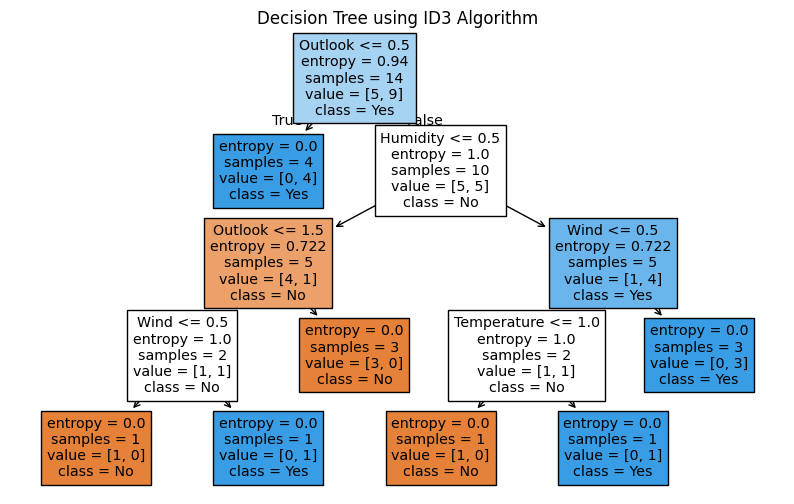


New Sample: Sunny, Cool, High, Strong
Predicted Class: No


In [10]:
data = [
['Sunny','Hot','High','Weak','No'],
['Sunny','Hot','High','Strong','No'],
['Overcast','Hot','High','Weak','Yes'],
['Rain','Mild','High','Weak','Yes'],
['Rain','Cool','Normal','Weak','Yes'],
['Rain','Cool','Normal','Strong','No'],
['Overcast','Cool','Normal','Strong','Yes'],
['Sunny','Mild','High','Weak','No'],
['Sunny','Cool','Normal','Weak','Yes'],
['Rain','Mild','Normal','Weak','Yes'],
['Sunny','Mild','Normal','Strong','Yes'],
['Overcast','Mild','High','Strong','Yes'],
['Overcast','Hot','Normal','Weak','Yes'],
['Rain','Mild','High','Strong','No']
]

columns = ['Outlook','Temperature','Humidity','Wind','PlayTennis']
df = pd.DataFrame(data, columns=columns)

print("Dataset:\n")
print(df)

def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    entropy_value = 0
    for i in range(len(elements)):
        p = counts[i] / np.sum(counts)
        entropy_value += -p * math.log2(p)
    return entropy_value

def information_gain(data, split_attribute, target_name="PlayTennis"):
    total_entropy = entropy(data[target_name])
    vals, counts = np.unique(data[split_attribute], return_counts=True)

    weighted_entropy = 0
    for i in range(len(vals)):
        subset = data[data[split_attribute] == vals[i]]
        weighted_entropy += (counts[i]/np.sum(counts)) * entropy(subset[target_name])

    return total_entropy - weighted_entropy

print("\nInformation Gain of Attributes:\n")

for col in df.columns[:-1]:
    print(col, ":", information_gain(df, col))

le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X, y)

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=df.columns[:-1],
          class_names=["No","Yes"],
          filled=True)
plt.title("Decision Tree using ID3 Algorithm")
plt.show()

new_sample = pd.DataFrame([['Sunny','Cool','High','Strong']],
                          columns=['Outlook','Temperature','Humidity','Wind'])

# Encode new sample
for col in new_sample.columns:
    new_sample[col] = le.fit(df[col]).transform(new_sample[col])

prediction = model.predict(new_sample)

print("\nNew Sample: Sunny, Cool, High, Strong")
print("Predicted Class:",
      "Yes" if prediction[0]==1 else "No")

4. Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the same using appropriate data sets.

In [15]:
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encode target labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.05):
        # Initialize weights
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        return z * (1 - z)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        # Error at output
        error = y - output
        d_output = error * self.sigmoid_derivative(output)

        # Error at hidden layer
        error_hidden = d_output.dot(self.W2.T)
        d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

        # Update weights
        self.W2 += self.a1.T.dot(d_output) * self.lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * self.lr
        self.W1 += X.T.dot(d_hidden) * self.lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * self.lr

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            if epoch % 100 == 0:
                loss = np.mean((y - output) ** 2)
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        output = self.forward(X)
        return np.argmax(output, axis=1)

nn = NeuralNetwork(input_size=4, hidden_size=6, output_size=3, learning_rate=0.05)
nn.train(X_train, y_train, epochs=1000)

# Predictions
y_pred = nn.predict(X_test)
y_true = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_true)
print("Test Accuracy:", accuracy)

Epoch 0, Loss: 0.2598
Epoch 100, Loss: 0.0221
Epoch 200, Loss: 0.0148
Epoch 300, Loss: 0.0127
Epoch 400, Loss: 0.0117
Epoch 500, Loss: 0.0111
Epoch 600, Loss: 0.0107
Epoch 700, Loss: 0.0105
Epoch 800, Loss: 0.0103
Epoch 900, Loss: 0.0102
Test Accuracy: 1.0
